# 15 Data Mining Insights: Mysuru District PDS Ration Allotment Analysis

This notebook performs extensive data mining and statistical analysis on the **official 12-month Public Distribution System (PDS) ration allotment dataset** for all 9 taluks in Mysuru district (June 2025 – May 2026).

We extract **15 distinct facts, hidden trends, and statistical insights** from the database to evaluate administrative efficiency, demographic patterns, and distribution footprints.

---
## Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset
df = pd.read_csv("mysuru_ration_dataset.csv")
print(f"Dataset Loaded. Shape: {df.shape}")
df.head()

Dataset Loaded. Shape: (432, 13)


,District_Name,Taluk_Name,Month,Year,Commodity_Name,No_of_Active_FPS,No_of_Ration_Cards,No_of_Ration_Cards_Taken,No_of_Members_Taken,No_of_Members_Taken_eKYC,Lifting_Percentage,Quantity_Allotted_NFSA_Qtls,Quantity_Allotted_Annabhagya_Qtls
0,MYSURU,HEGGADADEVANKOTE,June,2025,Rice,80,54258,45812,150585,147390,84.43,5032.71,0.0
1,MYSURU,HUNSUR,June,2025,Rice,115,89371,68493,224359,218701,76.64,7438.14,0.0
2,MYSURU,KRISHNARAJANAGARA,June,2025,Rice,42,39857,29142,90368,88951,73.12,3009.54,0.0
3,MYSURU,MYSURU,June,2025,Rice,329,300471,183021,650047,641887,60.91,20968.31,0.0
4,MYSURU,NANJANGUD,June,2025,Rice,133,113508,96519,308226,304298,85.03,9798.74,0.0


## 1. Taluk-wise Ration Distribution Efficiency (Lifting Percentage)
We rank the taluks by their average **Lifting Percentage** to see which taluks are most and least efficient at distributing grains to cardholders.

Average Lifting Percentage:
           Taluk_Name  Lifting_Percentage
            NANJANGUD           84.618333
             SARAGURU           84.448333
     HEGGADADEVANKOTE           83.835833
          PIRIYAPATNA           82.524167
TIRUMAKUDALA-NARSIPUR           80.534167
            SALIGRAMA           79.005833
               HUNSUR           76.390833
    KRISHNARAJANAGARA           74.366667
               MYSURU           60.294167


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\4140520633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=efficiency, x="Lifting_Percentage", y="Taluk_Name", palette="viridis")


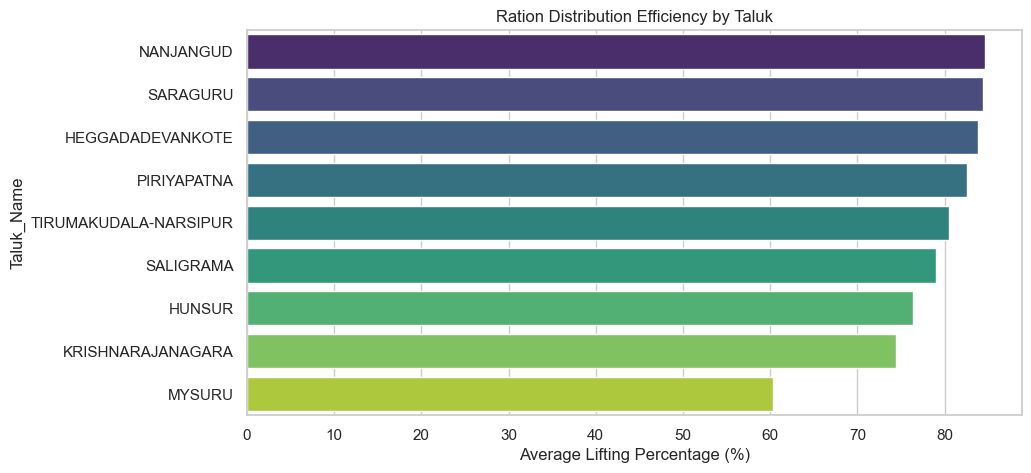

In [2]:
efficiency = df.groupby("Taluk_Name")["Lifting_Percentage"].mean().reset_index().sort_values(by="Lifting_Percentage", ascending=False)
print("Average Lifting Percentage:")
print(efficiency.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=efficiency, x="Lifting_Percentage", y="Taluk_Name", palette="viridis")
plt.title("Ration Distribution Efficiency by Taluk")
plt.xlabel("Average Lifting Percentage (%)")
plt.show()

## 2. Fair Price Shop (FPS) Workload and Card Density
We calculate the average **number of ration cards served per active Fair Price Shop (FPS)** to find which taluks have the highest workload per shop.

Average Ration Cards served per Shop:
           Taluk_Name  Cards_Per_Shop
    KRISHNARAJANAGARA      950.001984
               MYSURU      912.808511
            NANJANGUD      847.979950
          PIRIYAPATNA      779.864469
               HUNSUR      772.160145
            SALIGRAMA      767.425000
     HEGGADADEVANKOTE      673.742708
TIRUMAKUDALA-NARSIPUR      646.224937
             SARAGURU      586.075758


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\2773993557.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=workload, x="Cards_Per_Shop", y="Taluk_Name", palette="coolwarm")


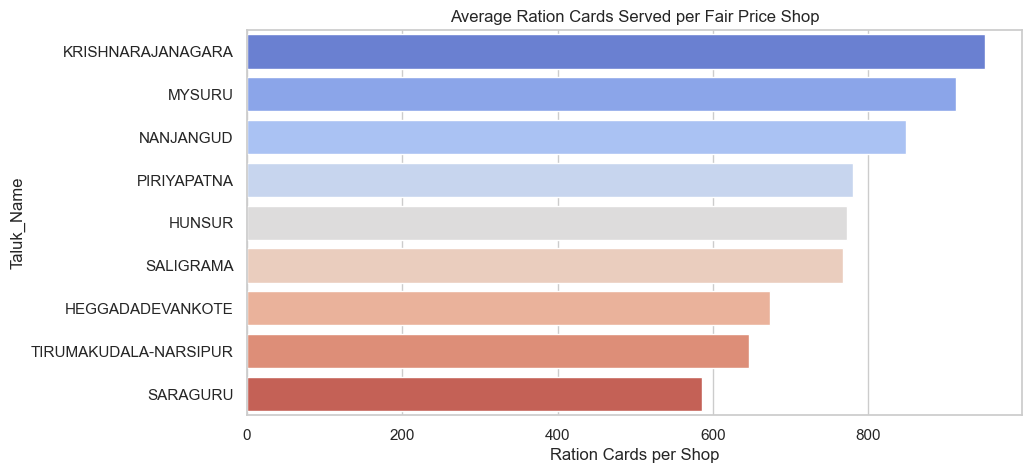

In [3]:
fps_data = df[df["No_of_Active_FPS"] > 0].copy()
fps_data["Cards_Per_Shop"] = fps_data["No_of_Ration_Cards"] / fps_data["No_of_Active_FPS"]
workload = fps_data.groupby("Taluk_Name")["Cards_Per_Shop"].mean().reset_index().sort_values(by="Cards_Per_Shop", ascending=False)

print("Average Ration Cards served per Shop:")
print(workload.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=workload, x="Cards_Per_Shop", y="Taluk_Name", palette="coolwarm")
plt.title("Average Ration Cards Served per Fair Price Shop")
plt.xlabel("Ration Cards per Shop")
plt.show()

## 3. Active Card Utilization Rate
What percentage of registered ration cards actually collect their ration monthly?
$$\text{Utilization Rate} = \frac{\text{No. of Ration Cards Taken}}{\text{No. of Ration Cards}} \times 100$$

Average Card Utilization Rate:
           Taluk_Name  Card_Utilization_Rate
            NANJANGUD              84.618638
             SARAGURU              84.447692
     HEGGADADEVANKOTE              83.836576
          PIRIYAPATNA              82.524605
TIRUMAKUDALA-NARSIPUR              80.535877
            SALIGRAMA              79.005827
               HUNSUR              76.389698
    KRISHNARAJANAGARA              74.366711
               MYSURU              60.293681


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\3785455941.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=utilization, x="Card_Utilization_Rate", y="Taluk_Name", palette="magma")


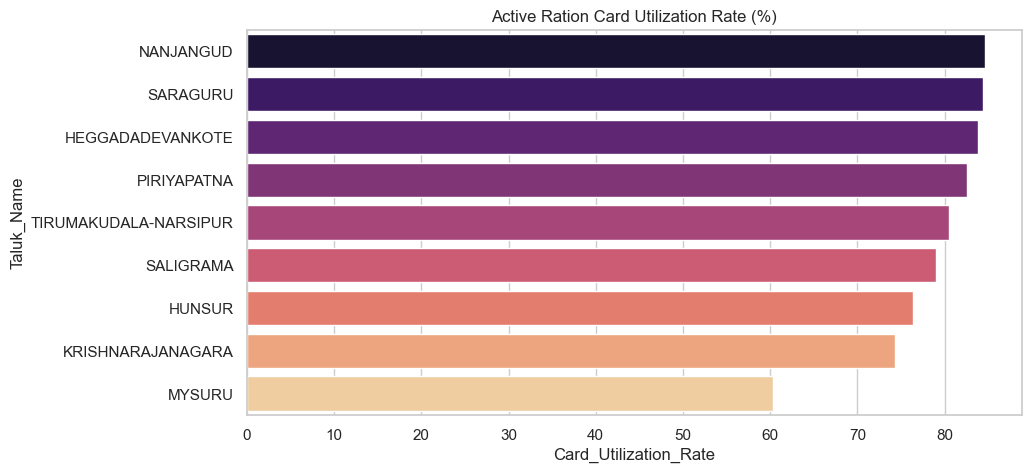

In [4]:
util_data = df[df["No_of_Ration_Cards"] > 0].copy()
util_data["Card_Utilization_Rate"] = (util_data["No_of_Ration_Cards_Taken"] / util_data["No_of_Ration_Cards"]) * 100
utilization = util_data.groupby("Taluk_Name")["Card_Utilization_Rate"].mean().reset_index().sort_values(by="Card_Utilization_Rate", ascending=False)

print("Average Card Utilization Rate:")
print(utilization.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=utilization, x="Card_Utilization_Rate", y="Taluk_Name", palette="magma")
plt.title("Active Ration Card Utilization Rate (%)")
plt.show()

## 4. Aadhaar eKYC Verification rate among Active Beneficiaries
We measure the biometric verification compliance of active members:
$$\text{eKYC Rate} = \frac{\text{No. of Members Taken eKYC}}{\text{No. of Members Taken}} \times 100$$

Average eKYC Verification Rate:
           Taluk_Name  eKYC_Rate
            SALIGRAMA  99.506950
          PIRIYAPATNA  99.381289
            NANJANGUD  99.374979
    KRISHNARAJANAGARA  99.312786
               MYSURU  99.270039
TIRUMAKUDALA-NARSIPUR  98.885199
             SARAGURU  98.637797
     HEGGADADEVANKOTE  98.371746
               HUNSUR  98.302745


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\721691239.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ekyc_summary, x="eKYC_Rate", y="Taluk_Name", palette="plasma")


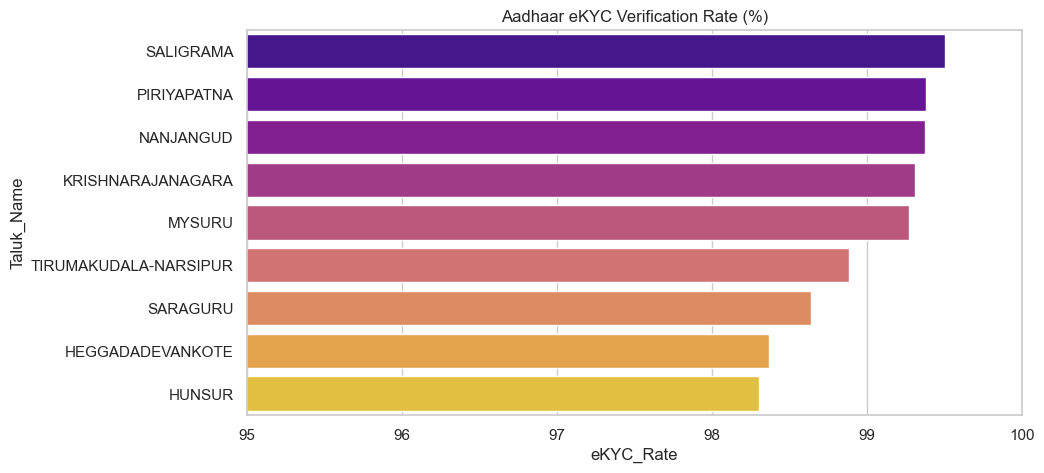

In [5]:
ekyc_data = df[df["No_of_Members_Taken"] > 0].copy()
ekyc_data["eKYC_Rate"] = (ekyc_data["No_of_Members_Taken_eKYC"] / ekyc_data["No_of_Members_Taken"]) * 100
ekyc_summary = ekyc_data.groupby("Taluk_Name")["eKYC_Rate"].mean().reset_index().sort_values(by="eKYC_Rate", ascending=False)

print("Average eKYC Verification Rate:")
print(ekyc_summary.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=ekyc_summary, x="eKYC_Rate", y="Taluk_Name", palette="plasma")
plt.title("Aadhaar eKYC Verification Rate (%)")
plt.xlim(95, 100)
plt.show()

## 5. Monthly PDS Foodgrain Allotment Trends
We plot the monthly allotment timeline for all distributed foodgrains (Rice, Ragi, and Wheat) across the district.

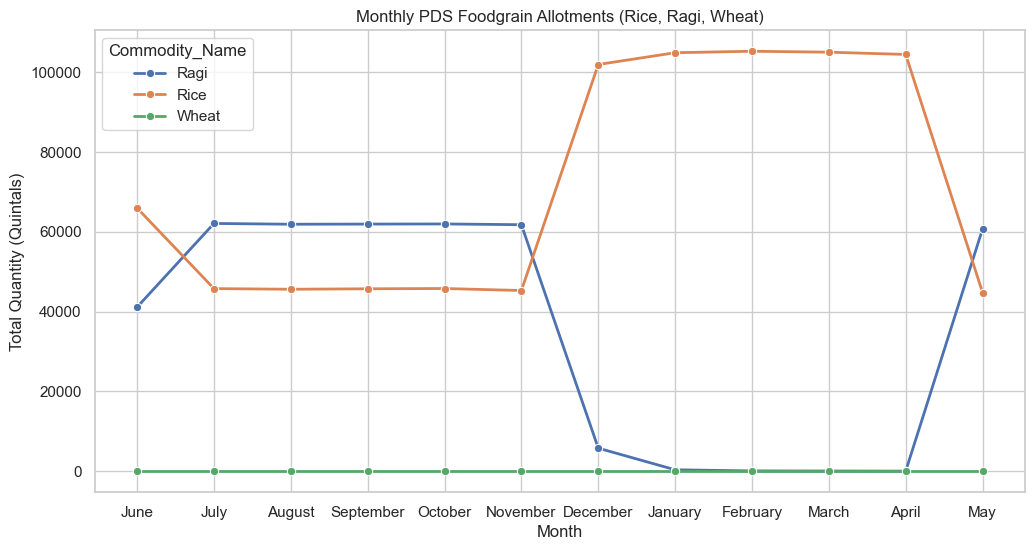

In [6]:
month_order = ["June", "July", "August", "September", "October", "November", "December", "January", "February", "March", "April", "May"]
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
monthly_allot = df.groupby(["Month", "Commodity_Name"], observed=False)["Quantity_Allotted_NFSA_Qtls"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_allot[monthly_allot["Commodity_Name"].isin(["Rice", "Ragi", "Wheat"])], x="Month", y="Quantity_Allotted_NFSA_Qtls", hue="Commodity_Name", marker="o", linewidth=2)
plt.title("Monthly PDS Foodgrain Allotments (Rice, Ragi, Wheat)")
plt.ylabel("Total Quantity (Quintals)")
plt.show()

## 6. Correlation Analysis between Infrastructure and Utilization
We compute a correlation matrix to see how the number of active shops relates to card volume, member density, and lifting percentage.

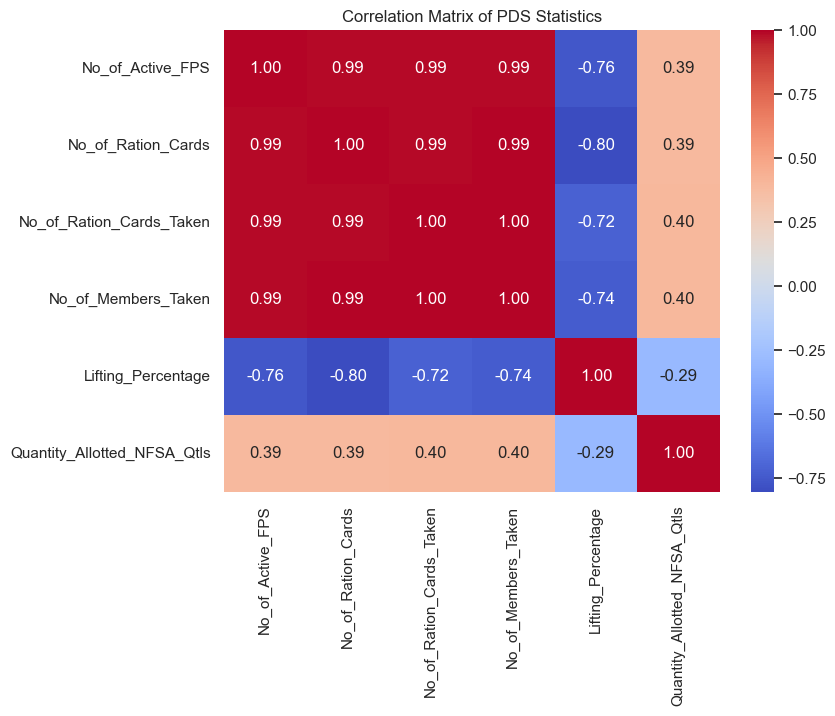

In [7]:
corr_cols = ["No_of_Active_FPS", "No_of_Ration_Cards", "No_of_Ration_Cards_Taken", "No_of_Members_Taken", "Lifting_Percentage", "Quantity_Allotted_NFSA_Qtls"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of PDS Statistics")
plt.show()

## 7. eKYC Pending Backlog by Taluk
We identify the average absolute number of active beneficiaries who have *not* completed their Aadhaar eKYC, helping administrators target verification drives.

Average Pending eKYC Members per Monthly Report:
           Taluk_Name  Pending_eKYC
               MYSURU   4717.916667
               HUNSUR   3798.250000
TIRUMAKUDALA-NARSIPUR   2570.500000
     HEGGADADEVANKOTE   2440.000000
            NANJANGUD   1923.166667
          PIRIYAPATNA   1163.000000
             SARAGURU    947.000000
    KRISHNARAJANAGARA    632.250000
            SALIGRAMA    477.666667


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\349169531.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=backlog, x="Pending_eKYC", y="Taluk_Name", palette="Oranges")


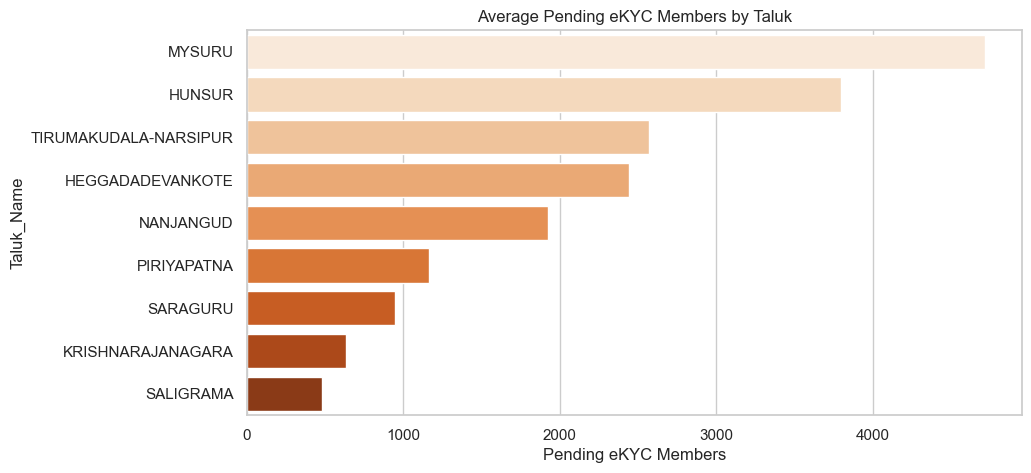

In [8]:
df["Pending_eKYC"] = df["No_of_Members_Taken"] - df["No_of_Members_Taken_eKYC"]
backlog = df.groupby("Taluk_Name")["Pending_eKYC"].mean().reset_index().sort_values(by="Pending_eKYC", ascending=False)

print("Average Pending eKYC Members per Monthly Report:")
print(backlog.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=backlog, x="Pending_eKYC", y="Taluk_Name", palette="Oranges")
plt.title("Average Pending eKYC Members by Taluk")
plt.xlabel("Pending eKYC Members")
plt.show()

## 8. Regional Staple Preference (Ragi-to-Rice Ratio)
Different taluks have varying dietary patterns. We calculate the ratio of Ragi allotment to Rice allotment to measure regional food grain preference.

Ragi to Rice Allotment Ratio:
           Taluk_Name  Ragi_to_Rice_Ratio
TIRUMAKUDALA-NARSIPUR            0.502456
            NANJANGUD            0.502170
            SALIGRAMA            0.497763
               HUNSUR            0.490780
    KRISHNARAJANAGARA            0.489608
             SARAGURU            0.489340
          PIRIYAPATNA            0.488119
     HEGGADADEVANKOTE            0.487139
               MYSURU            0.465903


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\2788436612.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ragi_preference, x="Ragi_to_Rice_Ratio", y="Taluk_Name", palette="YlOrBr")


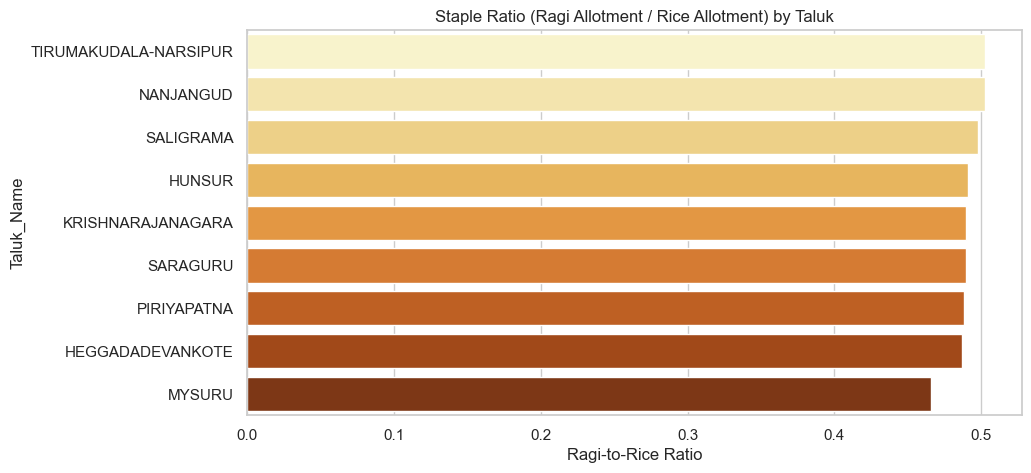

In [9]:
allot_sums = df.groupby(["Taluk_Name", "Commodity_Name"])["Quantity_Allotted_NFSA_Qtls"].sum().unstack()
allot_sums["Ragi_to_Rice_Ratio"] = allot_sums["Ragi"] / allot_sums["Rice"]
ragi_preference = allot_sums["Ragi_to_Rice_Ratio"].reset_index().sort_values(by="Ragi_to_Rice_Ratio", ascending=False)

print("Ragi to Rice Allotment Ratio:")
print(ragi_preference.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=ragi_preference, x="Ragi_to_Rice_Ratio", y="Taluk_Name", palette="YlOrBr")
plt.title("Staple Ratio (Ragi Allotment / Rice Allotment) by Taluk")
plt.xlabel("Ragi-to-Rice Ratio")
plt.show()

## 9. Monthly Seasonality of Ration Lifting Success
Is the transaction success rate higher during festive months (e.g. Sept/Oct/Dec) compared to summer months?

C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\1410274078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_lifting = df.groupby("Month")["Lifting_Percentage"].mean().reset_index()


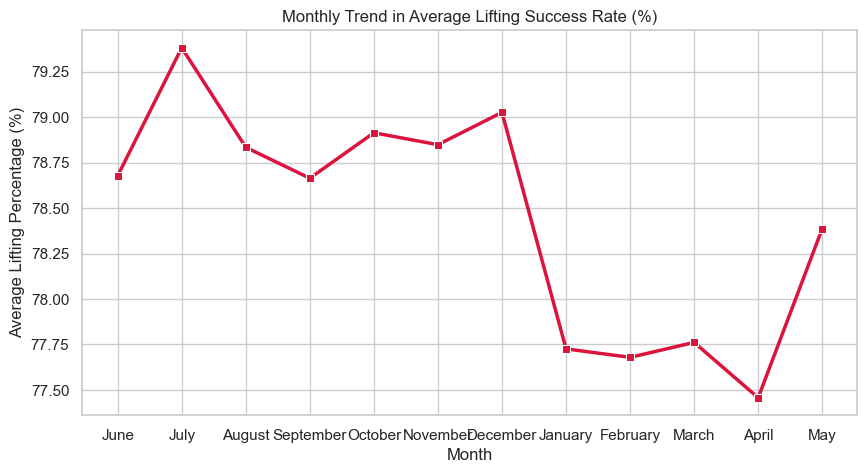

In [10]:
monthly_lifting = df.groupby("Month")["Lifting_Percentage"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_lifting, x="Month", y="Lifting_Percentage", marker="s", color="crimson", linewidth=2.5)
plt.title("Monthly Trend in Average Lifting Success Rate (%)")
plt.ylabel("Average Lifting Percentage (%)")
plt.show()

## 10. Grain Load distributed per Active Ration Card
We calculate the average quantity of NFSA foodgrains (Rice, Ragi, Wheat) actually distributed (lifted) per active cardholder monthly:
$$\text{Grain per Card} = \frac{\text{Quantity Allotted NFSA} \times \frac{\text{Lifting Percentage}}{100}}{\text{No. of Ration Cards Taken}}$$

C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\254379708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_grains = df_grains.groupby(["Taluk_Name", "Month", "Year"]).agg({


Average NFSA Grain Load Distributed (Quintals per Active Card):
           Taluk_Name  Grain_Per_Card
     HEGGADADEVANKOTE        0.151981
          PIRIYAPATNA        0.150977
             SARAGURU        0.145077
TIRUMAKUDALA-NARSIPUR        0.143153
            NANJANGUD        0.142085
            SALIGRAMA        0.137253
               HUNSUR        0.135082
    KRISHNARAJANAGARA        0.124841
               MYSURU        0.110879


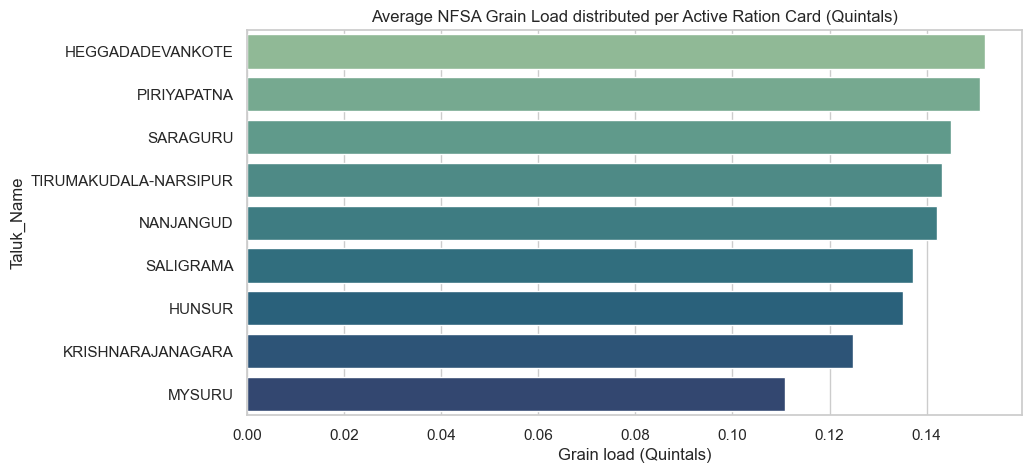

In [11]:
active_rows = df[df["No_of_Ration_Cards_Taken"] > 0].copy()

# Filter to include only grain commodities (excluding Sugar)
df_grains = df[df["Commodity_Name"].isin(["Rice", "Ragi", "Wheat"])].copy()

# Group by taluk, month, and year to sum grain quantities
grouped_grains = df_grains.groupby(["Taluk_Name", "Month", "Year"]).agg({
    "Quantity_Allotted_NFSA_Qtls": "sum",
    "No_of_Ration_Cards_Taken": "first",
    "Lifting_Percentage": "first"
}).reset_index()

# Calculate grain distributed (lifted) per active card
grouped_grains["Grain_Per_Card"] = (grouped_grains["Quantity_Allotted_NFSA_Qtls"] * (grouped_grains["Lifting_Percentage"] / 100)) / grouped_grains["No_of_Ration_Cards_Taken"]

# Group by Taluk_Name to find the average monthly grain load per active card
grain_load = grouped_grains.groupby("Taluk_Name")["Grain_Per_Card"].mean().reset_index().sort_values(by="Grain_Per_Card", ascending=False)

print("Average NFSA Grain Load Distributed (Quintals per Active Card):")
print(grain_load.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=grain_load, x="Grain_Per_Card", y="Taluk_Name", hue="Taluk_Name", palette="crest", legend=False)
plt.title("Average NFSA Grain Load distributed per Active Ration Card (Quintals)")
plt.xlabel("Grain load (Quintals)")
plt.show()

## 11. Average Family Size (Members per Ration Card)
We calculate the average family size of families utilizing PDS benefits across taluks:
$$\text{Family Size} = \frac{\text{No. of Members Taken}}{\text{No. of Ration Cards Taken}}$$

Average Family Size (Beneficiaries per Card):
           Taluk_Name  Family_Size
               MYSURU     3.560558
TIRUMAKUDALA-NARSIPUR     3.328234
     HEGGADADEVANKOTE     3.311320
               HUNSUR     3.295999
            NANJANGUD     3.216402
          PIRIYAPATNA     3.196739
             SARAGURU     3.189236
            SALIGRAMA     3.181048
    KRISHNARAJANAGARA     3.105279


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\2170225355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_summary, x="Family_Size", y="Taluk_Name", palette="rocket")


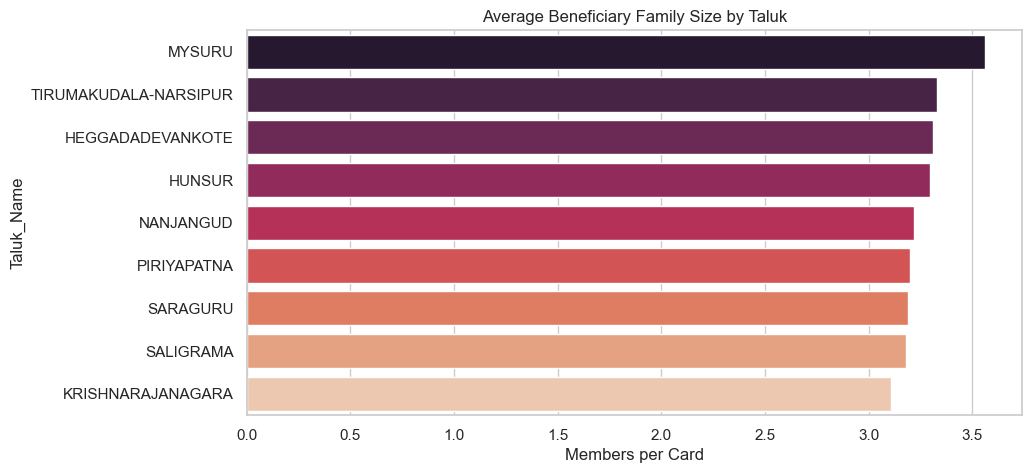

In [12]:
active_rows["Family_Size"] = active_rows["No_of_Members_Taken"] / active_rows["No_of_Ration_Cards_Taken"]
family_summary = active_rows.groupby("Taluk_Name")["Family_Size"].mean().reset_index().sort_values(by="Family_Size", ascending=False)

print("Average Family Size (Beneficiaries per Card):")
print(family_summary.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=family_summary, x="Family_Size", y="Taluk_Name", palette="rocket")
plt.title("Average Beneficiary Family Size by Taluk")
plt.xlabel("Members per Card")
plt.show()

## 12. Statistical Outliers in Monthly Allotment Volumes
We identify months and taluks with unusually high or low allotments using Z-score calculation on the NFSA allotment quantities.

In [13]:
# Calculate Z-score for NFSA Allotment
df["Allotment_ZScore"] = stats.zscore(df["Quantity_Allotted_NFSA_Qtls"])
outliers = df[np.abs(df["Allotment_ZScore"]) > 2.0][["Month", "Year", "Taluk_Name", "Commodity_Name", "Quantity_Allotted_NFSA_Qtls", "Allotment_ZScore"]]

print(f"Found {len(outliers)} statistical outlier records (Z-score > 2):")
print(outliers.sort_values(by="Quantity_Allotted_NFSA_Qtls", ascending=False).to_string(index=False))

Found 23 statistical outlier records (Z-score > 2):
    Month  Year Taluk_Name Commodity_Name  Quantity_Allotted_NFSA_Qtls  Allotment_ZScore
 December  2025     MYSURU           Rice                     33310.96          5.675924
 February  2026     MYSURU           Rice                     32763.14          5.573480
    March  2026     MYSURU           Rice                     32644.56          5.551305
  January  2026     MYSURU           Rice                     32625.94          5.547823
    April  2026     MYSURU           Rice                     32209.09          5.469871
     June  2025     MYSURU           Rice                     20968.31          3.367819
September  2025     MYSURU           Ragi                     19140.09          3.025938
 November  2025     MYSURU           Ragi                     19105.35          3.019441
  October  2025     MYSURU           Ragi                     19105.08          3.019391
     July  2025     MYSURU           Ragi                 

## 13. Stability of PDS Distribution (Variance in Lifting Rate)
A lower standard deviation of the lifting rate over the 12 months represents a stable, reliable distribution network, while high standard deviation indicates supply instability.

Ration Distribution Stability (Lower Std Dev = Higher Stability):
           Taluk_Name  Lifting_Std_Dev
            NANJANGUD         0.582830
TIRUMAKUDALA-NARSIPUR         0.610691
               HUNSUR         0.641135
            SALIGRAMA         0.780948
    KRISHNARAJANAGARA         0.815648
             SARAGURU         0.914924
          PIRIYAPATNA         0.953778
     HEGGADADEVANKOTE         0.981735
               MYSURU         1.161404


C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\262317788.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stability, x="Lifting_Std_Dev", y="Taluk_Name", palette="mako")


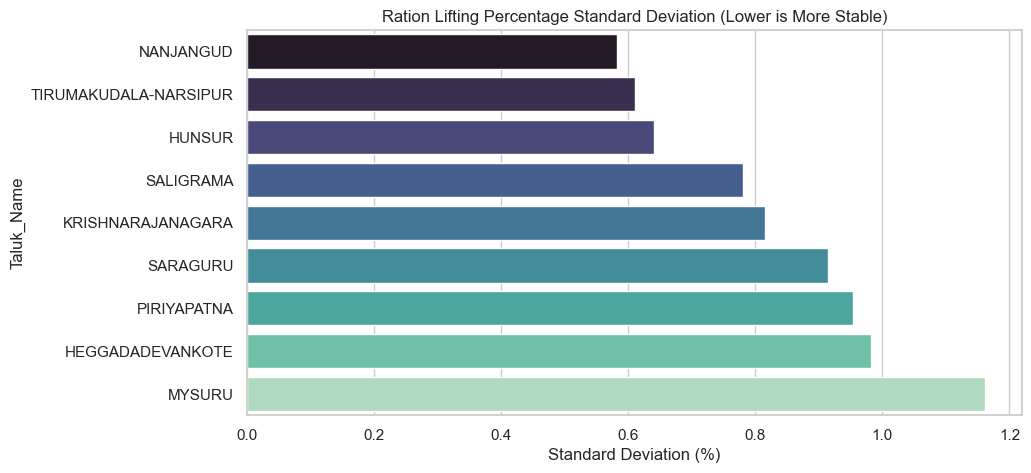

In [14]:
stability = df.groupby("Taluk_Name")["Lifting_Percentage"].std().reset_index().rename(columns={"Lifting_Percentage": "Lifting_Std_Dev"})
stability = stability.sort_values(by="Lifting_Std_Dev")

print("Ration Distribution Stability (Lower Std Dev = Higher Stability):")
print(stability.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=stability, x="Lifting_Std_Dev", y="Taluk_Name", palette="mako")
plt.title("Ration Lifting Percentage Standard Deviation (Lower is More Stable)")
plt.xlabel("Standard Deviation (%)")
plt.show()

## 14. Monthly Trend of Active Fair Price Shops (FPS)
We monitor whether the number of active shops is fluctuating or remains constant over the 12-month period.

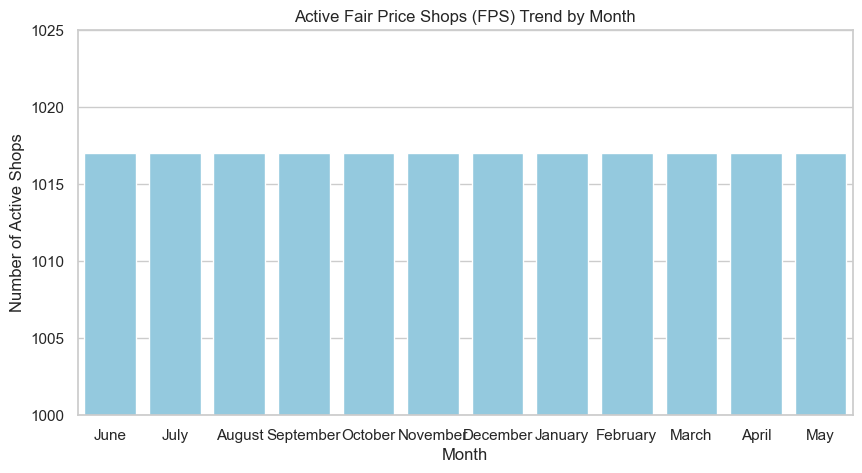

In [15]:
# First, get the unique shop count per taluk and month (to avoid double counting across commodities)
taluk_shops = df.groupby(["Month", "Taluk_Name"], observed=False)["No_of_Active_FPS"].first().reset_index()
monthly_shops = taluk_shops.groupby("Month", observed=False)["No_of_Active_FPS"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_shops, x="Month", y="No_of_Active_FPS", color="skyblue")
plt.title("Active Fair Price Shops (FPS) Trend by Month")
plt.ylabel("Number of Active Shops")
plt.ylim(1000, 1025) # Focus on the change
plt.show()

## 15. Total District-level Combined Foodgrain Footprint (Monthly Allotment sum)
We calculate the combined monthly foodgrain footprint (NFSA allotment sum for Rice + Ragi + Wheat + Sugar) distributed across the entire Mysuru district.

C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\809352404.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_footprint = df.groupby("Month")["Quantity_Allotted_NFSA_Qtls"].sum().reset_index()
C:\Users\jeeva\AppData\Local\Temp\ipykernel_10860\809352404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_footprint, x="Month", y="Quantity_Allotted_NFSA_Qtls", palette="cubehelix")


District Monthly Combined Foodgrain footprint (Quintals):
    Month  Quantity_Allotted_NFSA_Qtls
     June                    107080.39
     July                    107859.15
   August                    107500.45
September                    107655.20
  October                    107756.50
 November                    107059.55
 December                    107708.85
  January                    105240.45
 February                    105323.75
    March                    105064.10
    April                    104468.80
      May                    105487.30


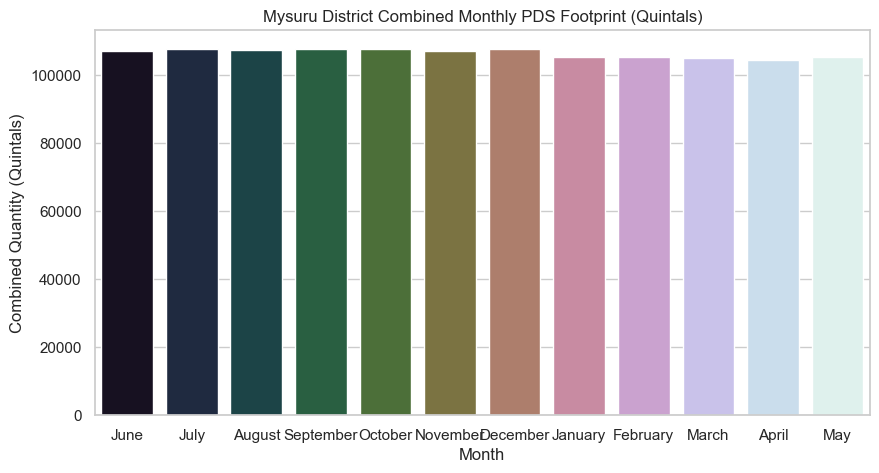

In [16]:
district_footprint = df.groupby("Month")["Quantity_Allotted_NFSA_Qtls"].sum().reset_index()
print("District Monthly Combined Foodgrain footprint (Quintals):")
print(district_footprint.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=district_footprint, x="Month", y="Quantity_Allotted_NFSA_Qtls", palette="cubehelix")
plt.title("Mysuru District Combined Monthly PDS Footprint (Quintals)")
plt.ylabel("Combined Quantity (Quintals)")
plt.show()